# Laboratory Day 9a: Semantic Segmentation (U-Net): Data, Tfrecord

In this exercise, we will prepare the data for training a U-Net using Tensorlow. We will learn how to work with "tfrecord", which is an efficient way to store and retrieve data. Before one starts this exercise, it is recommended to read through the tfrecord's tutorial: https://www.tensorflow.org/tutorials/load_data/tfrecord

## 1. Tfrecord (40 points)
**Exercise 1.1 Data Generator (10 points)**:
1. Download the Oxford pet dataset using the following links. Oxford pet dataset: https://www.robots.ox.ac.uk/~vgg/data/pets/

2. Unzip the .tar.gz files. Images are stored under directory "image". Image masks are stored under directory "annotations/trimaps". The dataset provides 3 types of labels: background (label_value=1), pet (label_value=0) and boundary (label_value=2). Images and masks are paired, if they have the same file name, e.g. image="image/Sphynx_103.jpg", mask="annotations/trimaps/Sphynx_103.png"
    
3. In this task, we aim to classify each pixel to "pet" (class=1) and "non-pet" (class=0, includes "background" and "boundary"). Class of "boundary" belong to "non-pet" class. Therefore, if a pixel in directory "annotation/trimaps" has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0. The total number of classes is 2.

4. Find out the paths of all pairs of images and masks. Separate this dataset into training set and validation set.

5. Write a Python generator function, which yields a pair of image and image mask. Image masks can be still viewed as images, which contain only two types of pixels.

6. Create two generators, one for the training set and the other for the validation set.   

!curl -O https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!curl -O https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

In [27]:
!curl -L -o images.tar.gz https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!curl -L -o annotations.tar.gz https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   187  100   187    0     0     99      0  0:00:01  0:00:01 --:--:--    99
100  755M  100  755M    0     0  18.7M      0  0:00:40  0:00:40 --:--:-- 20.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   187  100   187    0     0    242      0 --:--:-- --:--:-- --:--:--   242
100 18.2M  100 18.2M    0     0  6017k      0  0:00:03  0:00:03 --:--:-- 12.6M


In [28]:
import tarfile
import os

def extract_tar_gz(filename, expected_min_size_kb=100):
    if not os.path.exists(filename):
        print(f"Error: {filename} not found. Please ensure it is downloaded correctly in the previous cell.")
        return

    file_size_bytes = os.path.getsize(filename)

    if file_size_bytes < expected_min_size_kb * 1024:
        print(f"Warning: {filename} size ({file_size_bytes / 1024:.2f} KB) is unexpectedly small. This might indicate a failed download (e.g., HTML content instead of archive). Expected file size is much larger.")
        print("Please check the download command in the previous cell and ensure the file is correctly downloaded before attempting extraction.")
        return

    try:
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall()
        print(f"Successfully extracted {filename}")
    except tarfile.ReadError as e:
        print(f"Error extracting {filename}: {e}. This usually means the file is corrupted or not a valid gzip file. Please re-download it correctly.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction of {filename}: {e}")


# Extract images.tar.gz
extract_tar_gz('images.tar.gz', expected_min_size_kb=500000)

# Extract annotations.tar.gz
extract_tar_gz('annotations.tar.gz', expected_min_size_kb=10000)

/tmp/ipykernel_1627/385491771.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Successfully extracted images.tar.gz
Successfully extracted annotations.tar.gz


### Finding image and mask paths and splitting dataset

In [29]:
import glob
from sklearn.model_selection import train_test_split

image_dir = 'images'
annotation_dir = 'annotations/trimaps'

image_paths = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
mask_paths = sorted(glob.glob(os.path.join(annotation_dir, '*.png')))

# Ensure images and masks are correctly paired
pair_paths = []
for img_path in image_paths:
    img_filename = os.path.basename(img_path).replace('.jpg', '')
    mask_path = os.path.join(annotation_dir, img_filename + '.png')
    if os.path.exists(mask_path):
        pair_paths.append((img_path, mask_path))

# Separate into train and val
train_paths, val_paths = train_test_split(pair_paths, test_size=0.2, random_state=42)

print(f"Total paired images and masks: {len(pair_paths)}")
print(f"Training set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")

Total paired images and masks: 7390
Training set size: 5912
Validation set size: 1478


### Exercise 1.1: Data Generator

In [31]:
from PIL import Image
import numpy as np

def data_generator(file_paths):


    for im_path, mask_path in file_paths:

        image = Image.open(im_path).convert('RGB')
        image = np.array(image)


        mask = Image.open(mask_path).convert('L') # Convert to grayscale
        mask = np.array(mask) # mask will have values 1, 2, 3 (background, pet, boundary)



        # Create a new mask array for binary classification
        binary_mask = np.zeros_like(mask, dtype=np.uint8)
        binary_mask[mask == 1] = 0
        binary_mask[mask == 2] = 0
        binary_mask[mask == 3] = 0


        # Target: pet (1), non-pet (0)
        binary_mask[mask == 1] = 1
        binary_mask[mask == 2] = 0
        binary_mask[mask == 3] = 0

        # Masks should have a channel dimension
        binary_mask = np.expand_dims(binary_mask, axis=-1)

        yield image, binary_mask


train_data_gen = data_generator(train_paths)
val_data_gen = data_generator(val_paths)

### Test the data generator

Displaying 3 examples from the training generator:


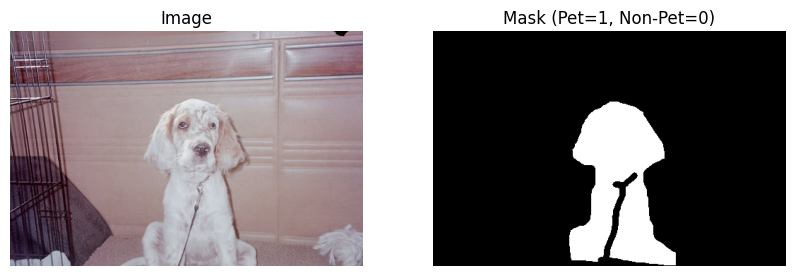

Image shape: (333, 500, 3), Mask shape: (333, 500, 1)
Unique mask values: [0 1]


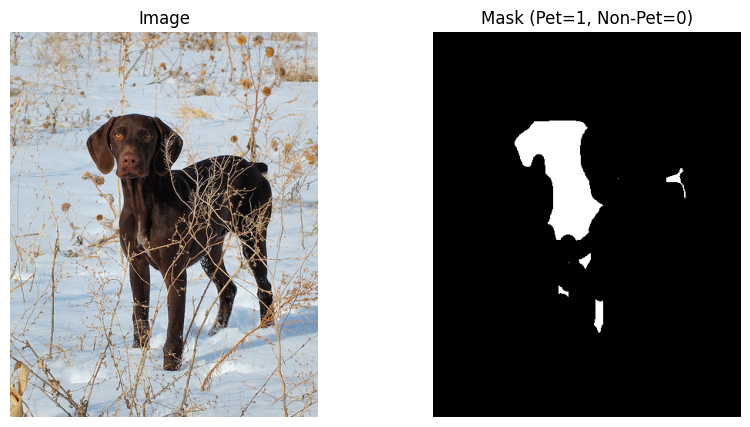

Image shape: (500, 400, 3), Mask shape: (500, 400, 1)
Unique mask values: [0 1]


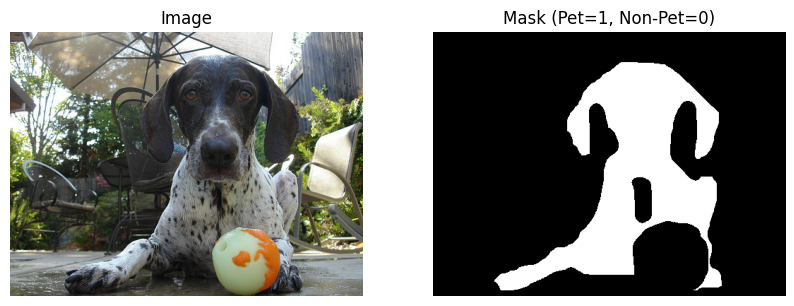

Image shape: (375, 500, 3), Mask shape: (375, 500, 1)
Unique mask values: [0 1]

Displaying 1 example from the validation generator:


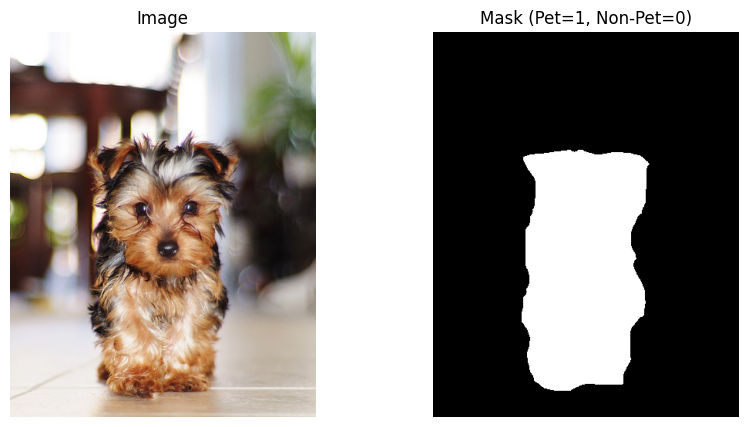

Image shape: (500, 397, 3), Mask shape: (500, 397, 1)
Unique mask values: [0 1]


In [34]:
import matplotlib.pyplot as plt

# Test the training data generator
print("Displaying 3 examples from the training generator:")
for i, (image, mask) in enumerate(train_data_gen):
    if i >= 3: break
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title('Image')
    axes[0].axis('off')


    axes[1].imshow(mask.squeeze(), cmap='gray')
    axes[1].set_title('Mask (Pet=1, Non-Pet=0)')
    axes[1].axis('off')
    plt.show()

    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    print(f"Unique mask values: {np.unique(mask)}")

# Test the validation data generator
print("\nDisplaying 1 example from the validation generator:")
for i, (image, mask) in enumerate(val_data_gen):
     if i >= 1: break
     fig, axes = plt.subplots(1, 2, figsize=(10, 5))
     axes[0].imshow(image)
     axes[0].set_title('Image')
     axes[0].axis('off')
     axes[1].imshow(mask.squeeze(), cmap='gray')
     axes[1].set_title('Mask (Pet=1, Non-Pet=0)')
     axes[1].axis('off')
     plt.show()
     print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
     print(f"Unique mask values: {np.unique(mask)}")

**Exercise 1.2 Data Augmentation (10 points)**

The downloaded dataset contains limited images and image masks. Data augmentation is typically used to improve network accuracy and to avoid overfitting. By using data augmentation, you can add more variety to the training data.

In this exercise, we will implement data argumentation before the training time.

Tasks:

Please write a data augmentation function (a python generator), which randomly adds some (2 to 3 types) of the following effects to the dataset: e.g. Gaussian blurring, Gaussian random noise, random rotation, random crop, random padding, random contrast adjustment. Feel free to add more effects to the dataset. All image libraries, e.g. PIL, scikit-image, can be used.

Please visualize a few examples before and after data augmentation (for quick evaluation of your solution).

Note: If you are not able to finish this task, you could go head and solve the following tasks. However, the training process may be less optimal at the end.


In [37]:
from PIL import Image, ImageFilter
import numpy as np
import random

def gaussian_blurring(image, mask):
    image = Image.fromarray(image)
    mask = Image.fromarray(mask.squeeze())

    image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0)))


    return np.array(image), np.expand_dims(np.array(mask), axis=-1)

def random_rotation(image, mask):
    angle = random.randint(-20, 20) # Rotate between -20 and +20 degrees
    image = Image.fromarray(image)
    mask = Image.fromarray(mask.squeeze())

    image = image.rotate(angle, resample=Image.BICUBIC, expand=False)
    mask = mask.rotate(angle, resample=Image.NEAREST, expand=False)
    # Use NEAREST for masks to preserve discrete labels

    return np.array(image), np.expand_dims(np.array(mask), axis=-1)

def random_horizontal_flip(image, mask):
    if random.random() > 0.5:
        image = Image.fromarray(image).transpose(Image.FLIP_LEFT_RIGHT)
        mask = Image.fromarray(mask.squeeze()).transpose(Image.FLIP_LEFT_RIGHT)

    return np.array(image), np.expand_dims(np.array(mask), axis=-1)

def data_augmentation(data_generator, num_augmentation=1):
    # data_generator: the generator from the previous exercise
    # num_augmentation: each image is augmented for num_augmentation times

    augmentation_ops = [
        gaussian_blurring,
        random_rotation,
        random_horizontal_flip
    ]

    for image, image_mask in data_generator:
        yield image, image_mask

        for _ in range(num_augmentation):

            num_ops_to_apply = random.randint(2, 3)
            randomly_selected_ops = random.sample(augmentation_ops, num_ops_to_apply)

            augmented_image = image
            augmented_mask = image_mask

            for op in randomly_selected_ops:
                augmented_image, augmented_mask = op(augmented_image, augmented_mask)
            yield augmented_image, augmented_mask


# Create augmented generators


train_data_gen_base = data_generator(train_paths)
val_data_gen_base = data_generator(val_paths)

augmented_train_data_gen = data_augmentation(train_data_gen_base, num_augmentation=2) # Each original image yields 1 original + 2 augmented
augmented_val_data_gen = data_augmentation(val_data_gen_base, num_augmentation=1) # Each original image yields 1 original + 1 augmented

### Visualization of Data Augmentation
Let's visualize an example of the `gaussian_blurring` effect.

Visualizing Gaussian Blurring:


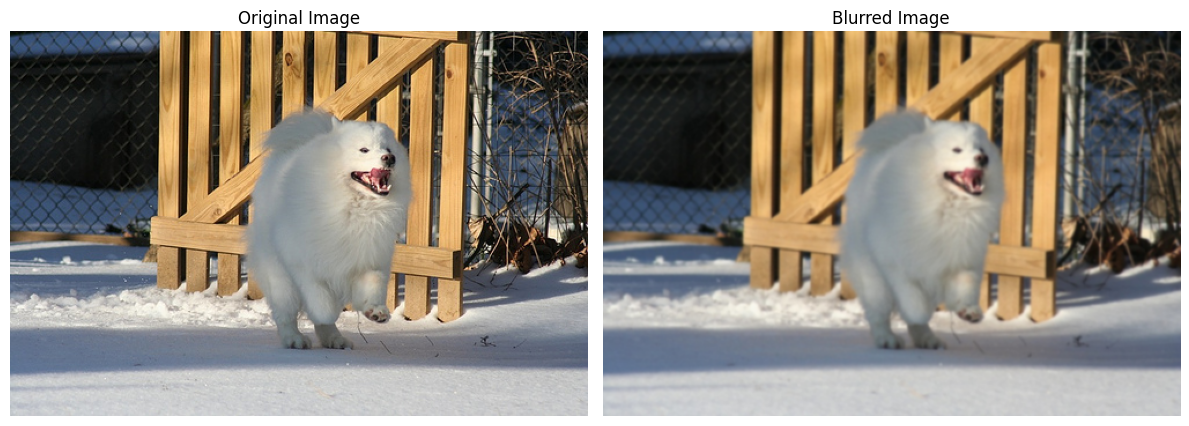


Visualizing Random Rotation:


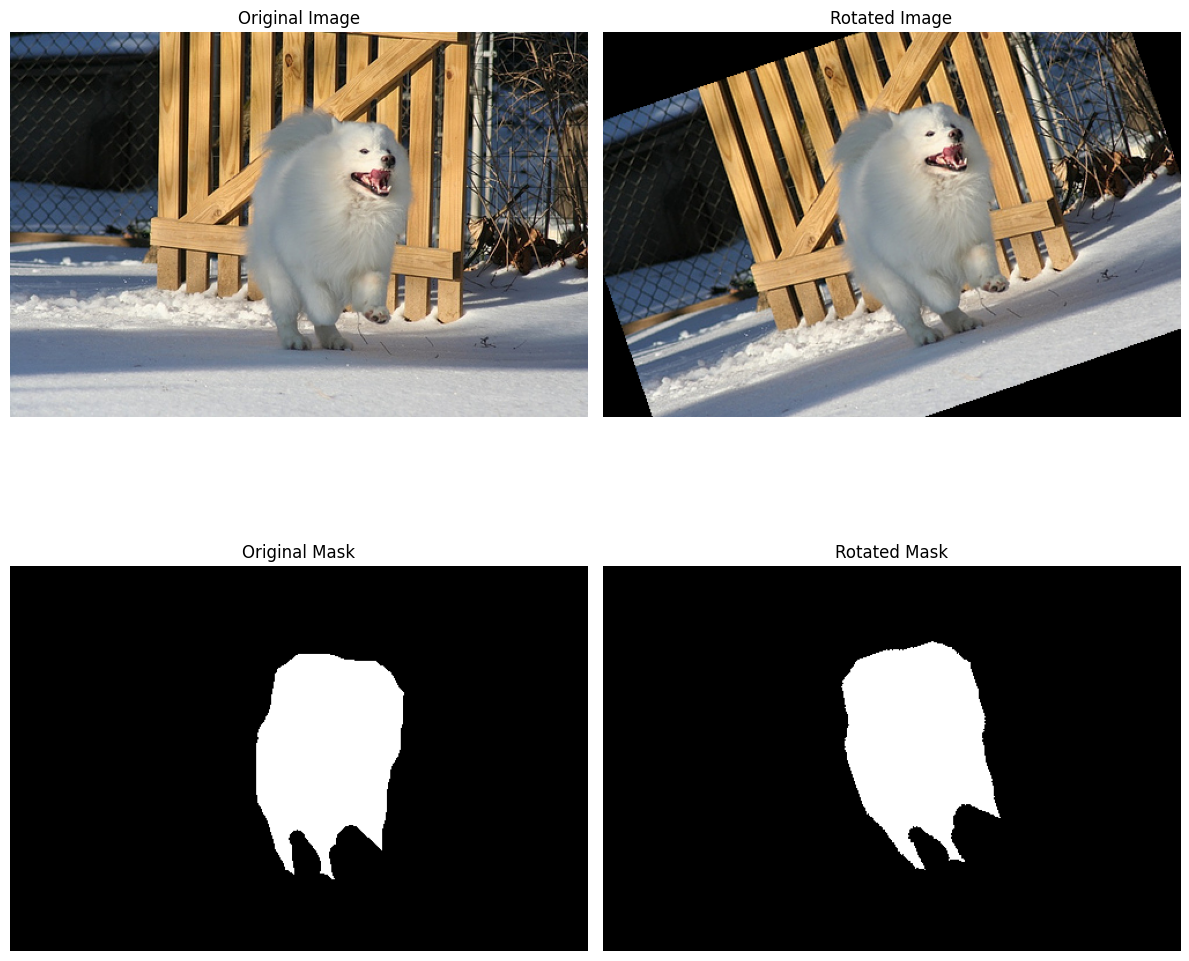


Visualizing Random Horizontal Flip:


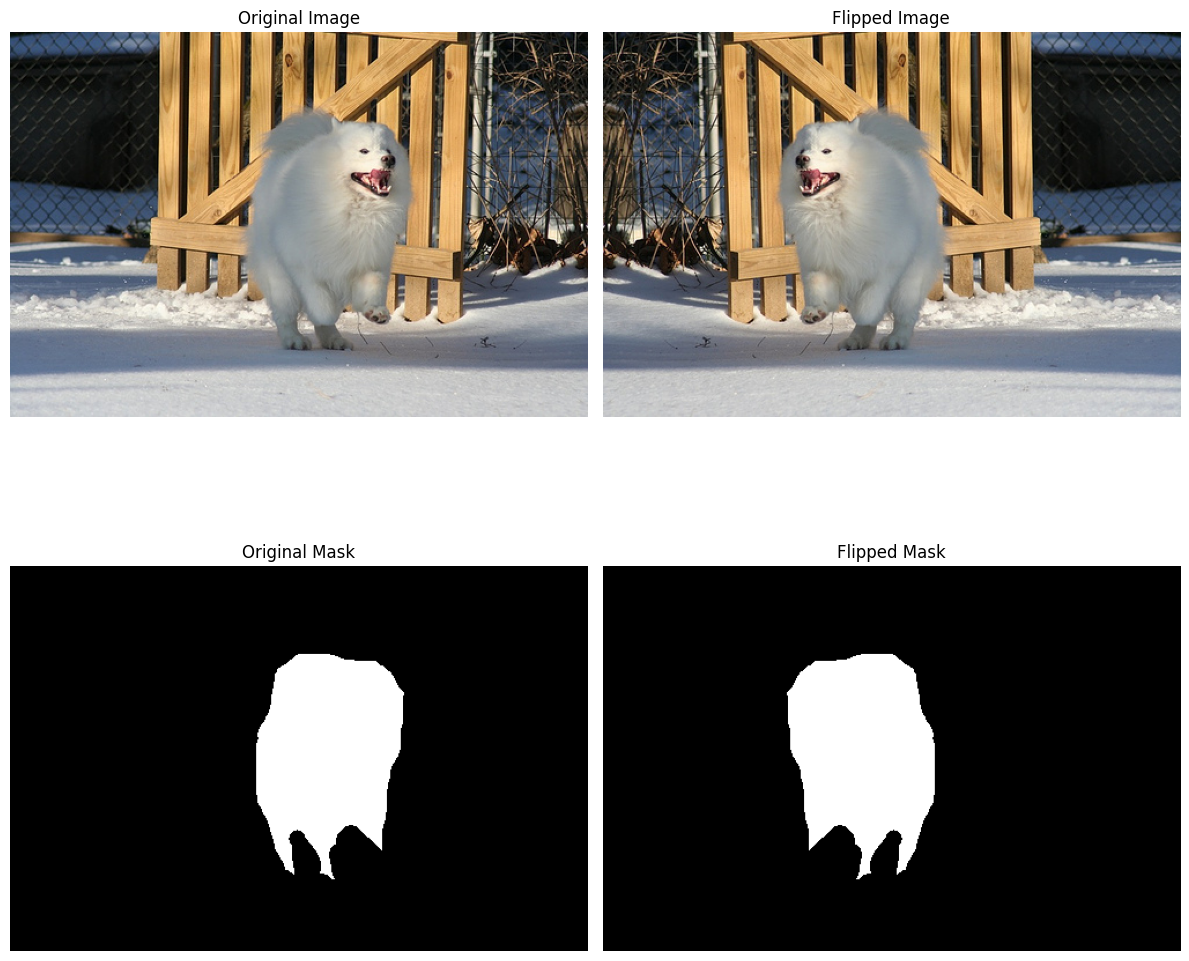

In [38]:
import matplotlib.pyplot as plt


example_train_gen = data_generator(train_paths[:1])
original_image, original_mask = next(example_train_gen)

print("Visualizing Gaussian Blurring:")
# Apply gaussian blurring
blurred_image, _ = gaussian_blurring(original_image.copy(), original_mask.copy())

# Display the original and blurred images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(blurred_image)
axes[1].set_title('Blurred Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("\nVisualizing Random Rotation:")
# Apply random rotation
rotated_image, rotated_mask = random_rotation(original_image.copy(), original_mask.copy())

# Display the original and rotated images and masks
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')
axes[0, 1].imshow(rotated_image)
axes[0, 1].set_title('Rotated Image')
axes[0, 1].axis('off')
axes[1, 0].imshow(original_mask.squeeze(), cmap='gray')
axes[1, 0].set_title('Original Mask')
axes[1, 0].axis('off')
axes[1, 1].imshow(rotated_mask.squeeze(), cmap='gray')
axes[1, 1].set_title('Rotated Mask')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

print("\nVisualizing Random Horizontal Flip:")
# Apply random horizontal flip
flipped_image, flipped_mask = random_horizontal_flip(original_image.copy(), original_mask.copy())

# Display the original and flipped images and masks
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')
axes[0, 1].imshow(flipped_image)
axes[0, 1].set_title('Flipped Image')
axes[0, 1].axis('off')
axes[1, 0].imshow(original_mask.squeeze(), cmap='gray')
axes[1, 0].set_title('Original Mask')
axes[1, 0].axis('off')
axes[1, 1].imshow(flipped_mask.squeeze(), cmap='gray')
axes[1, 1].set_title('Flipped Mask')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

**Exercise 1.3 Tfrecord Creation(10 points)**:
1. Based on the developed data generator, convert training and validation data into 2 tfrecord ("train.tfrecord", "val.tfrecord").

2. Each record in a tfrecord should contain one image and one image's mask.

3. Tutorial of tfrecord can be found here: https://www.tensorflow.org/tutorials/load_data/tfrecord#walkthrough_reading_and_writing_image_data

4. Code example to create tfrecord is provided (tfrecord_parse.py). You can use the functions there.

5. Make sure that the image pair can be converted to tfrecord files and retrieved from tfrecord files in both directions.

6. For task evaluation, Please retrieve the image and the image mask from a generated tfrecord file and visualize 2-3 examples.

In [39]:
import tensorflow as tf

def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    if isinstance(value, type(tf.constant(0))): # BytesList won't unpack a string from an EagerTensor.
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _float_feature(value):
    """Returns a float_list from a float / double."""
    return tf.train.Feature(float_list=tf.train.FloatList(value=[value]))

def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(image, mask):
    feature = {
        'image_raw': _bytes_feature(tf.io.serialize_tensor(image)),
        'mask_raw': _bytes_feature(tf.io.serialize_tensor(mask))
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

def write_tfrecords(data_generator, output_filename, num_examples):
    with tf.io.TFRecordWriter(output_filename) as writer:
        for i, (image, mask) in enumerate(data_generator):
            if i >= num_examples:
                break
            # Convert numpy arrays to tensors before serialization
            image_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
            mask_tensor = tf.convert_to_tensor(mask, dtype=tf.uint8)

            example = serialize_example(image_tensor, mask_tensor)
            writer.write(example)
    print(f"Successfully wrote {i+1} examples to {output_filename}")


# Calculate the total number of augmented training and validation examples
# (Original + num_augmentation * Original)
num_train_examples = len(train_paths) * (1 + 2) # 1 original + 2 augmented
num_val_examples = len(val_paths) * (1 + 1)   # 1 original + 1 augmented

# Create TFRecord files
print("Creating train.tfrecord...")
write_tfrecords(augmented_train_data_gen, 'train.tfrecord', num_train_examples)

print("Creating val.tfrecord...")
write_tfrecords(augmented_val_data_gen, 'val.tfrecord', num_val_examples)


Creating train.tfrecord...
Successfully wrote 17736 examples to train.tfrecord
Creating val.tfrecord...
Successfully wrote 2956 examples to val.tfrecord


**Exercise 1.4 Data pipeline (10 points)** :
1. Build data pipelines for the training and validation data, using tf.data.TFRecordDataset(tfrecord_path).

2. For the training dataset, please apply the following operations: (a) repeat the dataset (b) shuffle the dataset (c) convert the record to a pair of image and image mask (d) resize the image and the image mask to 572 * 572 * 3 (e) make up batches with proper batch size.

    - The training dataset is repeated. So we can train the network for any large number of steps.
    
    - 572 * 572 * 3 is the input dimension of U-Net. Optional, if you have memory issues, one could use reduced height and width as the input dimension of U-Net.
    
    - If the images are not with dimension 572*572, they have to be resized during the training time. Optional, one can also resize images during tfrecord generation. Both options are acceptable.

    - If you do not have enough computational power, one could use a reduced input size, e.g. $300*300*3$.

3. For validation dataset, please apply the following operations: (a) convert the record to image and image mask (b) resize the image (c) make up batches.

    - The validation dataset is not repeated. We can evaluate the network's performance regarding the entire validation tfrecord.

4. Test that image and image mask can be retrieved from this data pipeline using e.g. for-loop. Visualize a few examples, which are feed into the network directly.

5. Print out the dimension of the retrieved image and image mask.

Training Dataset created.
Validation Dataset created.

Visualizing 2 examples from the training pipeline:
Batch 1:
  Image batch shape: (16, 572, 572, 3)
  Mask batch shape: (16, 572, 572, 1)


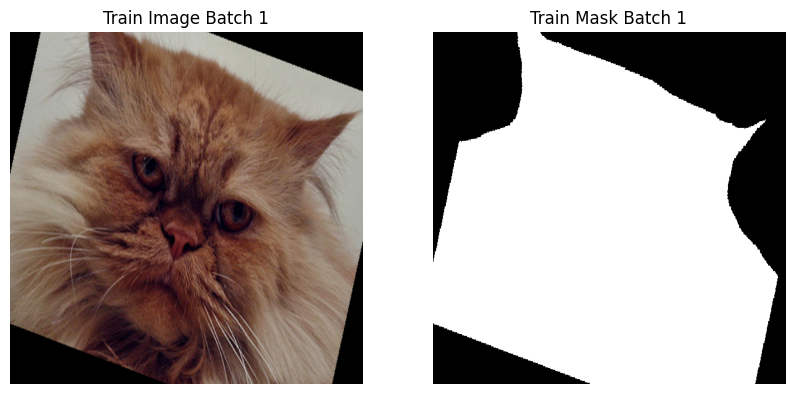

Batch 2:
  Image batch shape: (16, 572, 572, 3)
  Mask batch shape: (16, 572, 572, 1)


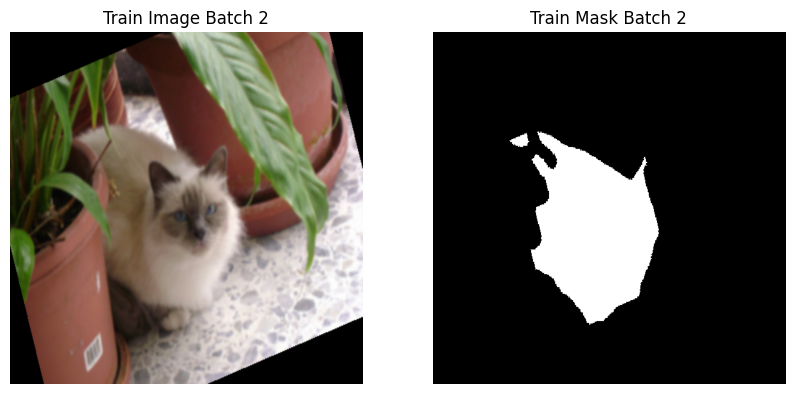


Visualizing 1 example from the validation pipeline:
Batch 1:
  Image batch shape: (16, 572, 572, 3)
  Mask batch shape: (16, 572, 572, 1)


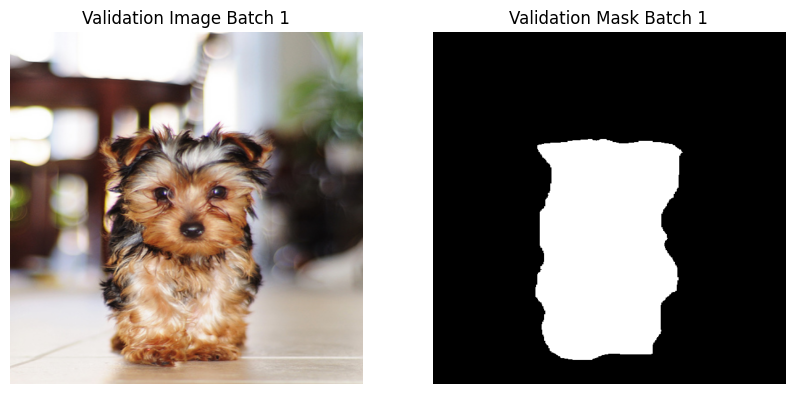

In [45]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Define image dimensions
IMG_HEIGHT = 572
IMG_WIDTH = 572

def decode_fn(serialized_example):

    feature_description = {
        'image_raw': tf.io.FixedLenFeature([], tf.string),
        'mask_raw': tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(serialized_example, feature_description)


    image = tf.io.parse_tensor(example['image_raw'], out_type=tf.uint8)
    mask = tf.io.parse_tensor(example['mask_raw'], out_type=tf.uint8)


    mask = tf.squeeze(mask)
    mask = tf.expand_dims(mask, axis=-1) # Re-add channel dimension if it was completely removed by squeeze (e.g., from [H,W,1] to [H,W])


    image = tf.ensure_shape(image, [None, None, 3])
    mask = tf.ensure_shape(mask, [None, None, 1])

    return image, mask

def preprocess_fn(image, mask, target_height, target_width):


    # Resize image and mask
    image = tf.image.resize(image, [target_height, target_width], method=tf.image.ResizeMethod.BILINEAR)
    mask = tf.image.resize(mask, [target_height, target_width], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Normalize image to [0, 1] range
    image = tf.cast(image, tf.float32) / 255.0

    return image, mask

def create_dataset(tfrecord_path, batch_size, is_training):
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    dataset = dataset.map(decode_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)
        dataset = dataset.repeat()

    # Preprocess (resize and normalize)
    dataset = dataset.map(lambda image, mask: preprocess_fn(image, mask, IMG_HEIGHT, IMG_WIDTH), num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

# Create training and validation datasets
BATCH_SIZE = 16 # You can adjust this based on your memory

train_dataset = create_dataset('train.tfrecord', BATCH_SIZE, is_training=True)
val_dataset = create_dataset('val.tfrecord', BATCH_SIZE, is_training=False)

print("Training Dataset created.")
print("Validation Dataset created.")


# Test data pipeline and visualize a few examples
print("\nVisualizing 2 examples from the training pipeline:")
for i, (image_batch, mask_batch) in enumerate(train_dataset.take(2)):
    print(f"Batch {i+1}:")
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Mask batch shape: {mask_batch.shape}")

    # Display first image and mask from the batch
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_batch[0].numpy()) # Denormalize for display if needed, but for now it's [0,1]
    axes[0].set_title(f'Train Image Batch {i+1}')
    axes[0].axis('off')
    axes[1].imshow(mask_batch[0].numpy().squeeze(), cmap='gray')
    axes[1].set_title(f'Train Mask Batch {i+1}')
    axes[1].axis('off')
    plt.show()

print("\nVisualizing 1 example from the validation pipeline:")
for i, (image_batch, mask_batch) in enumerate(val_dataset.take(1)):
    print(f"Batch {i+1}:")
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Mask batch shape: {mask_batch.shape}")

    # Display first image and mask from the batch
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_batch[0].numpy())
    axes[0].set_title(f'Validation Image Batch {i+1}')
    axes[0].axis('off')
    axes[1].imshow(mask_batch[0].numpy().squeeze(), cmap='gray')
    axes[1].set_title(f'Validation Mask Batch {i+1}')
    axes[1].axis('off')
    plt.show()